# **Практическая работа №10. Сравнение моделей классификации изображений и развертывание API**

## **Цель работы**

Провести сравнительный анализ ранее обученных моделей классификации изображений (работы 2-5), выбрать лучшую по метрикам качества, развернуть ее в виде API и создать пользовательский интерфейс с помощью Streamlit.

---

### **Раздел 1. Подготовка и анализ моделей**

1. Загрузить выбранный датасет для классификации изображений
2. Загрузить ранее обученные модели (из практических работ 2-5)
3. Сравнить модели по метрикам качества:
   - Точность (accuracy)
   - Полнота (recall)
   - Precision
   - F1-мера
   - Время инференса
4. Создать сводный DataFrame с результатами всех моделей
5. Визуализировать результаты сравнения с помощью графиков
6. Построить матрицы ошибок для каждой модели
7. Выбрать лучшую модель по F1-мере
8. Сохранить лучшую модель

In [1]:
import os, time, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Flatten, Conv2D, MaxPooling2D, Dropout,
    BatchNormalization, Input, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print('TF version:', tf.__version__)

2026-05-11 16:14:00.937485: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778516040.949335    8868 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778516040.952624    8868 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TF version: 2.18.0


#### 1.1. Загрузка датасета Fashion MNIST

In [2]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
NUM_CLASSES = 10

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = fashion_mnist.load_data()

x_train = x_train_raw.astype('float32') / 255.0
x_test  = x_test_raw.astype('float32')  / 255.0

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test.reshape(-1, 28, 28, 1)

x_train_flat = x_train.reshape(-1, 784)
x_test_flat  = x_test.reshape(-1, 784)

y_train_cat = to_categorical(y_train_raw, NUM_CLASSES)
y_test_cat  = to_categorical(y_test_raw,  NUM_CLASSES)

# Данные для MobileNetV2: 28x28 grayscale -> 32x32 RGB
x_train_mob = np.repeat(x_train_cnn, 3, axis=-1)
x_train_mob = tf.image.resize(x_train_mob, (32, 32)).numpy()
x_test_mob  = np.repeat(x_test_cnn, 3, axis=-1)
x_test_mob  = tf.image.resize(x_test_mob, (32, 32)).numpy()

print(f'Train: {x_train.shape}, Test: {x_test.shape}')
print(f'MobileNetV2 input: {x_train_mob.shape}')

2026-05-11 16:14:03.155754: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Train: (60000, 28, 28), Test: (10000, 28, 28)
MobileNetV2 input: (60000, 32, 32, 3)


#### 1.2. Визуализация данных

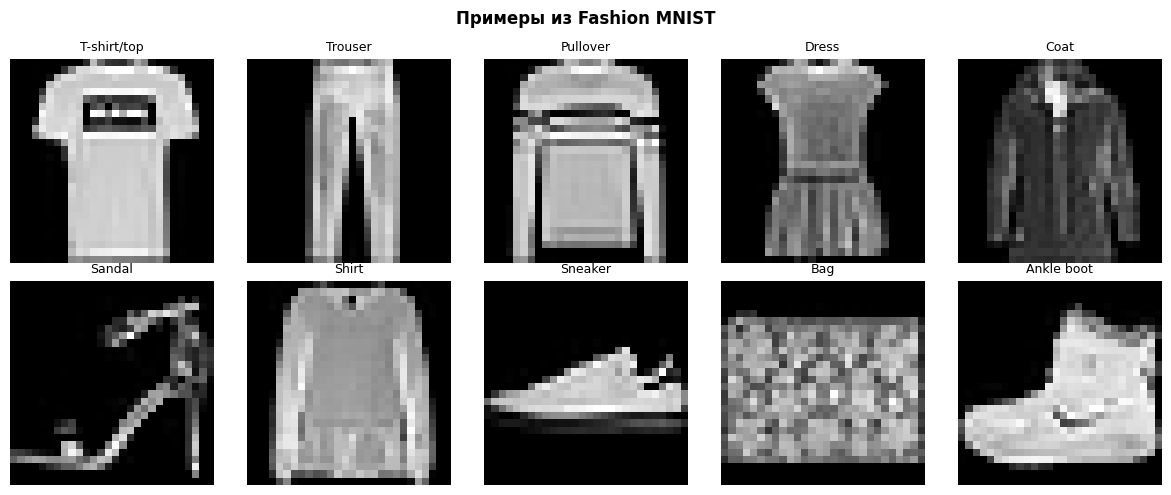

In [3]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    idx = np.where(y_train_raw == i)[0][0]
    plt.imshow(x_train_raw[idx], cmap='gray')
    plt.title(CLASS_NAMES[i], fontsize=9)
    plt.axis('off')
plt.suptitle('Примеры из Fashion MNIST', fontweight='bold')
plt.tight_layout()
plt.show()

#### 1.3. Определение архитектур моделей

In [4]:
def build_dnn():
    """Практическая 2: Полносвязная нейронная сеть (Dense)"""
    return Sequential([
        Input(shape=(784,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='DNN_Practical2')

def build_cnn():
    """Практическая 3: CNN без BatchNorm и Dropout"""
    return Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='CNN_Practical3')

def build_cnn_bn_do():
    """Практическая 4: CNN с BatchNormalization и Dropout"""
    return Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.25),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.25),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.25),
        Flatten(),
        Dense(256, activation='relu'), BatchNormalization(), Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='CNN_BN_DO_Practical4')

def build_mobilenet():
    """Практическая 5: Transfer Learning с MobileNetV2"""
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    inp = Input(shape=(32, 32, 3))
    x = base(inp, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='MobileNetV2_Practical5')

print('Архитектуры моделей определены.')

Архитектуры моделей определены.


#### 1.4. Обучение и оценка моделей

In [5]:
EPOCHS = 10
BATCH = 128

configs = [
    ('DNN (Практ. 2)',          build_dnn,       x_train_flat, x_test_flat),
    ('CNN (Практ. 3)',          build_cnn,       x_train_cnn,  x_test_cnn),
    ('CNN+BN+DO (Практ. 4)',   build_cnn_bn_do, x_train_cnn,  x_test_cnn),
    ('MobileNetV2 (Практ. 5)', build_mobilenet,  x_train_mob,  x_test_mob),
]

results = []
all_preds = {}
trained_models = {}

for name, builder, x_tr, x_te in configs:
    print(f'\n{"="*60}')
    print(f'Обучение: {name}')
    print(f'{"="*60}')
    
    model = builder()
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    model.fit(x_tr, y_train_cat, validation_split=0.15,
              epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=1)
    
    # Время инференса
    times = []
    for _ in range(3):
        t0 = time.time()
        model.predict(x_te, batch_size=256, verbose=0)
        times.append(time.time() - t0)
    avg_time = np.mean(times)
    per_img_ms = (avg_time / len(x_te)) * 1000
    
    # Метрики
    probs = model.predict(x_te, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    
    acc  = accuracy_score(y_test_raw, y_pred)
    prec = precision_score(y_test_raw, y_pred, average='weighted')
    rec  = recall_score(y_test_raw, y_pred, average='weighted')
    f1   = f1_score(y_test_raw, y_pred, average='weighted')
    
    results.append({
        'Модель': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
        'Recall': round(rec,4), 'F1-мера': round(f1,4),
        'Время инф. (с)': round(avg_time,3), 'Время/изобр. (мс)': round(per_img_ms,4)
    })
    all_preds[name] = (y_pred, probs)
    trained_models[name] = model
    print(f'  Acc={acc:.4f}, F1={f1:.4f}, Время={per_img_ms:.4f} мс/изобр.')


Обучение: DNN (Практ. 2)
Epoch 1/10


  1/399 ━━━━━━━━━━━━━━━━━━━━ 4:54 741ms/step - accuracy: 0.0547 - loss: 2.3458

 12/399 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3808 - loss: 1.8051    

 24/399 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4757 - loss: 1.5244

 37/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5292 - loss: 1.3546

...

395/399 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6713 - loss: 0.8982

397/399 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6712 - loss: 0.8983

399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6712 - loss: 0.8983

399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6687 - loss: 0.9035 - val_accuracy: 0.6706 - val_loss: 0.9115


  Acc=0.6699, F1=0.6699, Время=0.2363 мс/изобр.


#### 1.5. Сводная таблица результатов

In [6]:
df = pd.DataFrame(results)
print('\nСВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
print('=' * 70)
df


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ


,Модель,Accuracy,Precision,Recall,F1-мера,Время инф. (с),Время/изобр. (мс)
0,DNN (Практ. 2),0.8785,0.8796,0.8785,0.8774,0.158,0.0158
1,CNN (Практ. 3),0.9157,0.9163,0.9157,0.9159,0.593,0.0593
2,CNN+BN+DO (Практ. 4),0.9106,0.9112,0.9106,0.9094,0.737,0.0737
3,MobileNetV2 (Практ. 5),0.6699,0.6916,0.6699,0.6699,2.363,0.2363


#### 1.6. Визуализация сравнения метрик

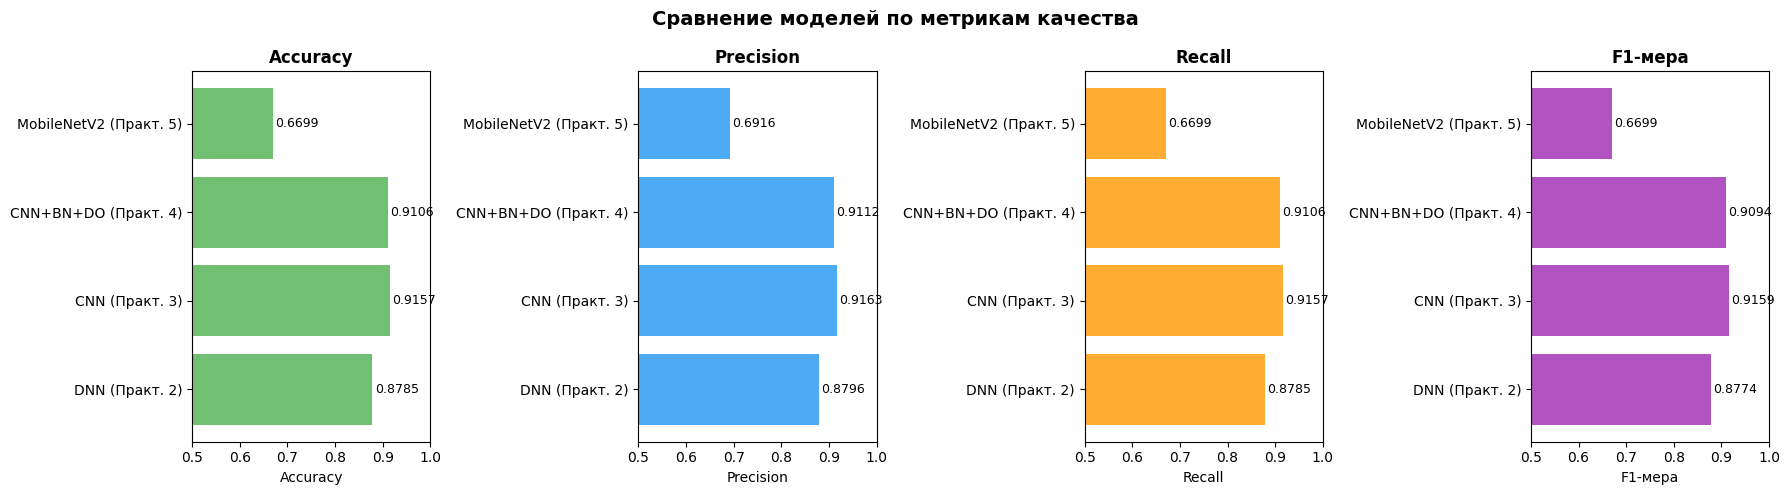

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-мера']
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.barh(df['Модель'], df[metric], color=color, alpha=0.8)
    ax.set_xlabel(metric)
    ax.set_xlim(0.5, 1.0)
    for bar, val in zip(bars, df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(metric, fontweight='bold')

plt.suptitle('Сравнение моделей по метрикам качества', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 1.7. Сравнение времени инференса

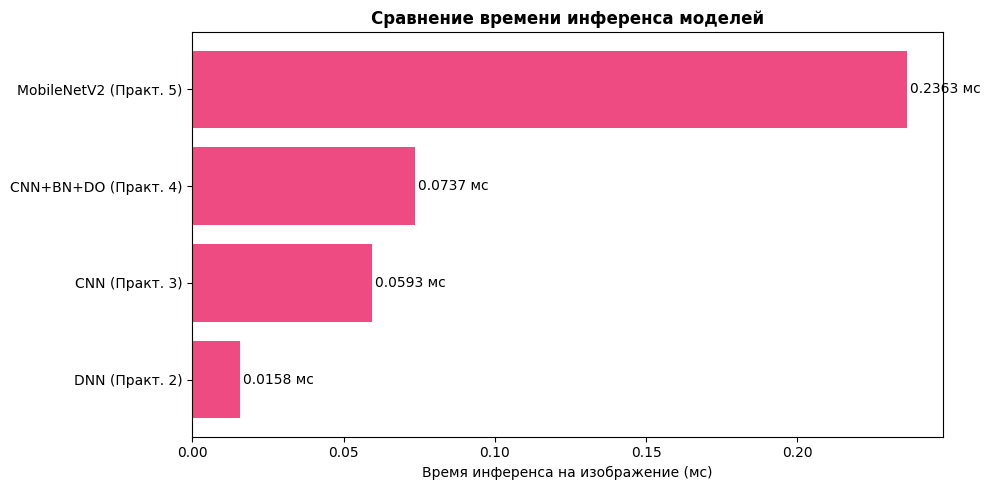

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df['Модель'], df['Время/изобр. (мс)'], color='#E91E63', alpha=0.8)
for bar, val in zip(bars, df['Время/изобр. (мс)']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} мс', va='center', fontsize=10)
ax.set_xlabel('Время инференса на изображение (мс)')
ax.set_title('Сравнение времени инференса моделей', fontweight='bold')
plt.tight_layout()
plt.show()

#### 1.8. Матрицы ошибок

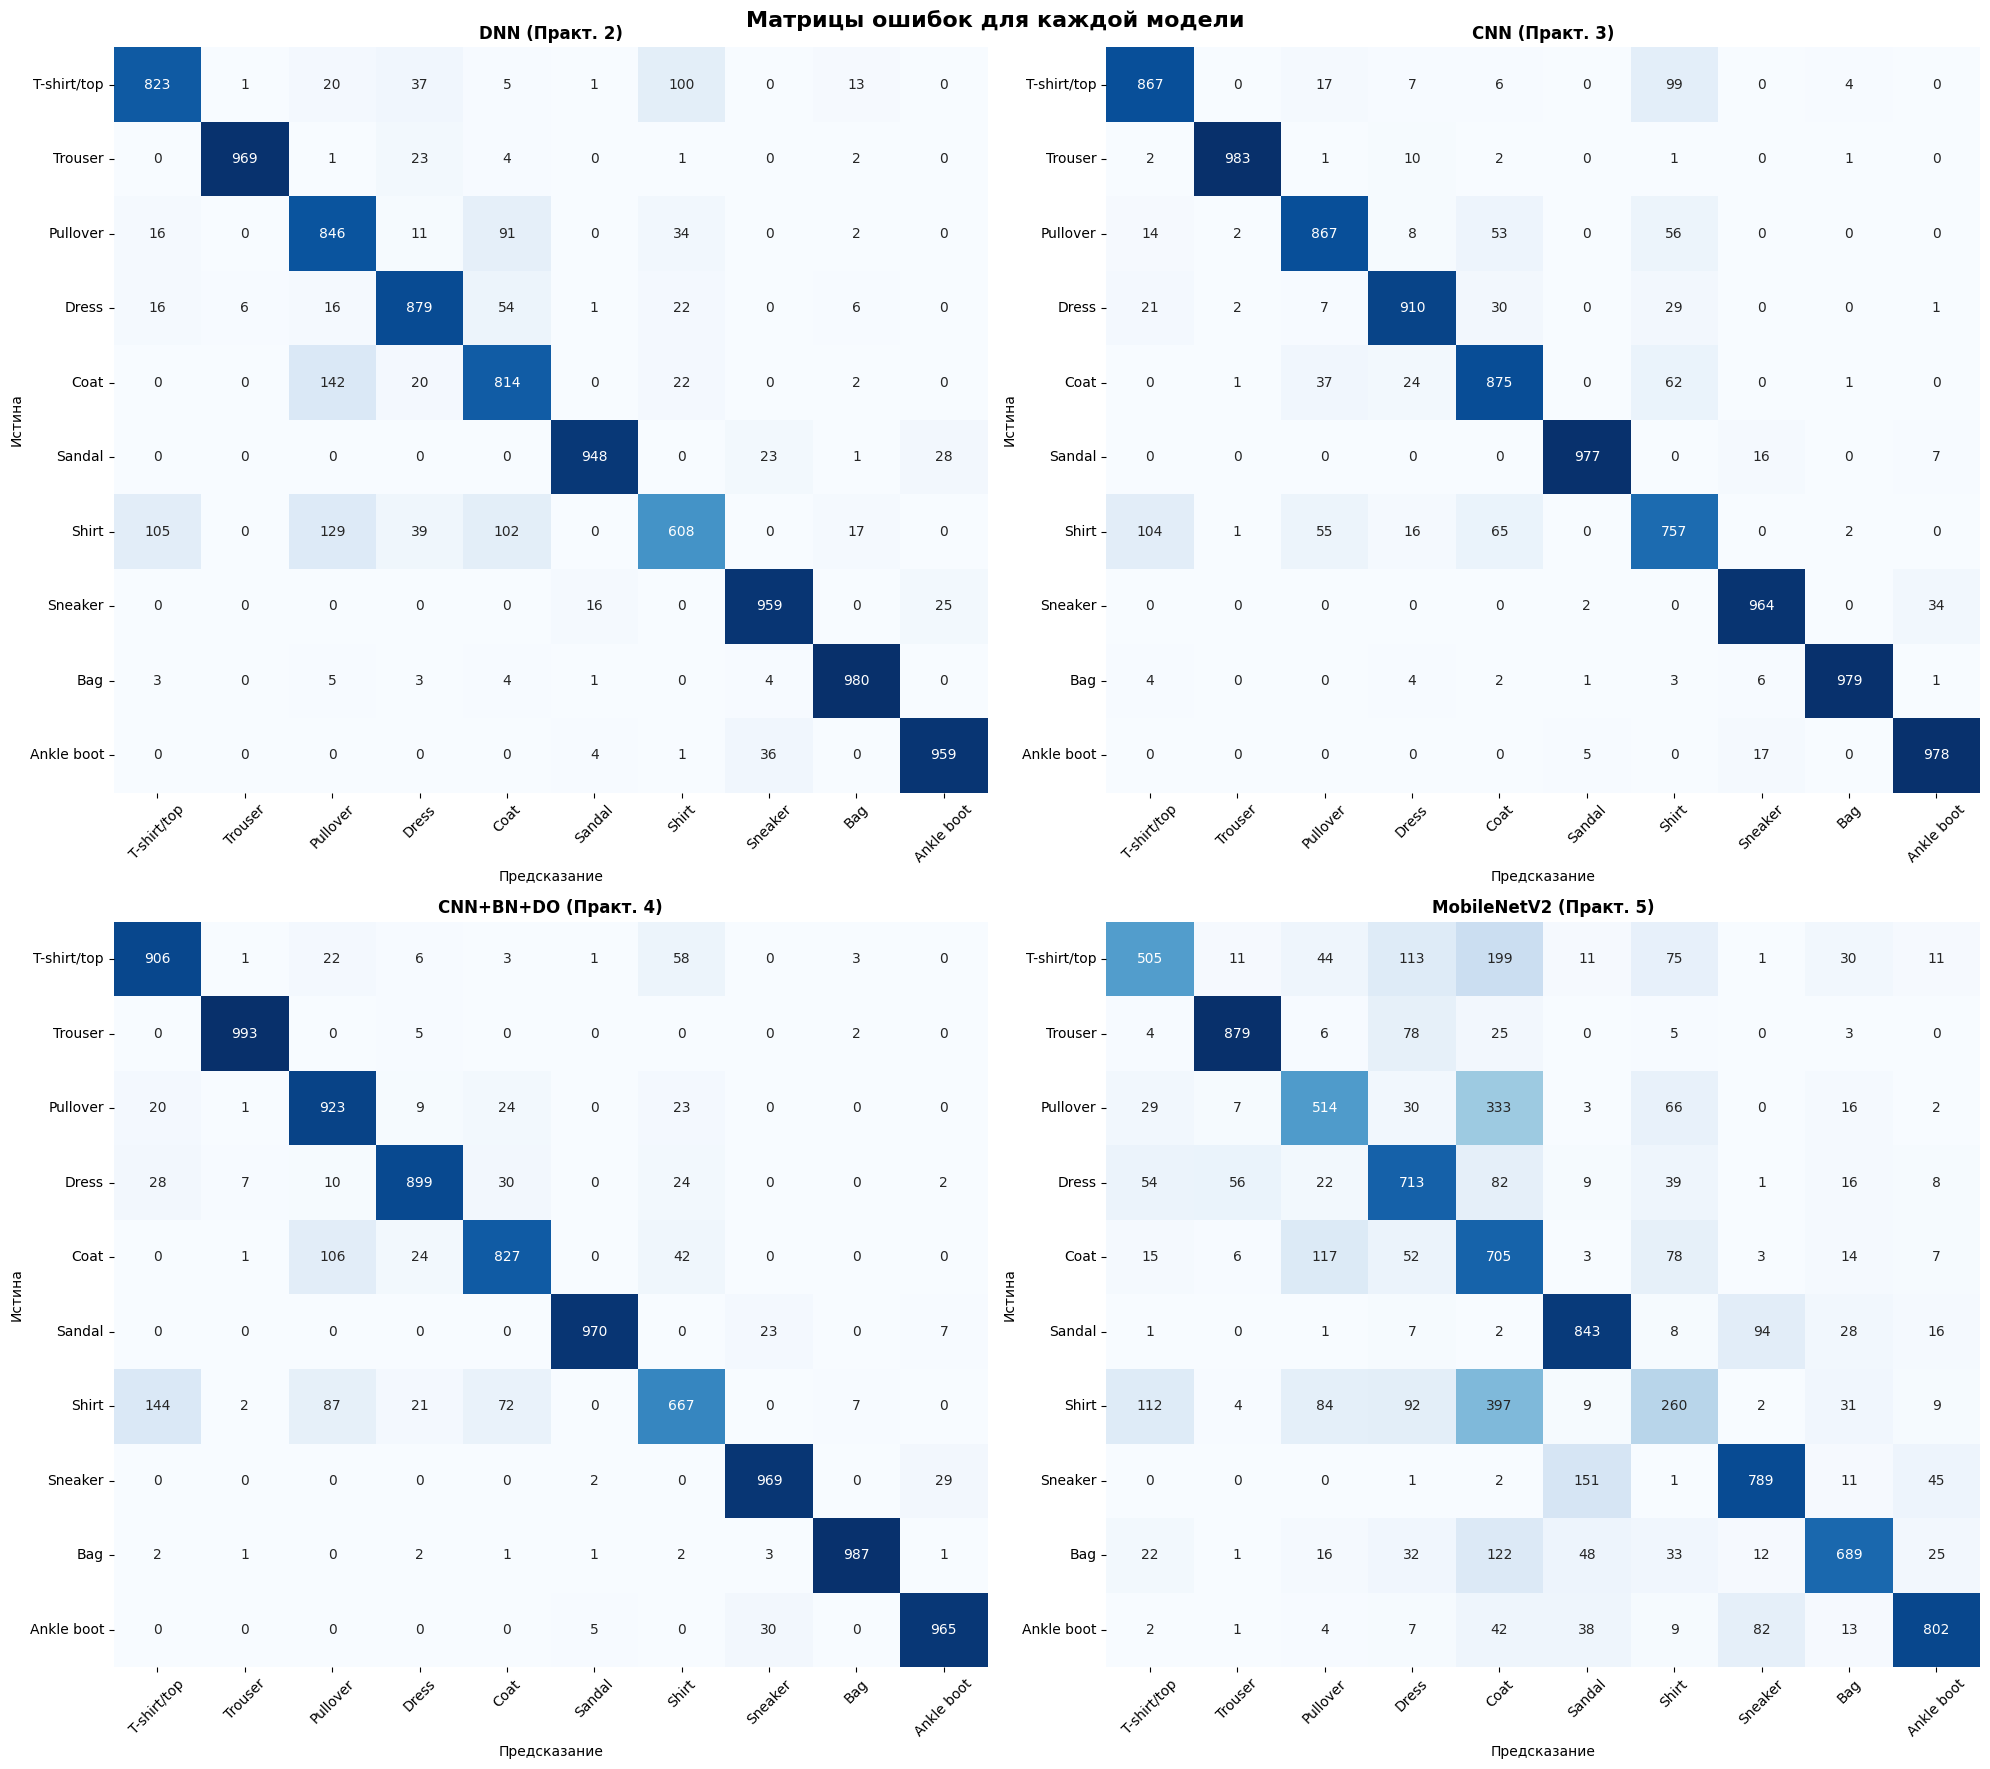

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
for ax, (name, (y_pred, _)) in zip(axes.flat, all_preds.items()):
    cm = confusion_matrix(y_test_raw, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истина')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Матрицы ошибок для каждой модели', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### 1.9. Сводное сравнение метрик

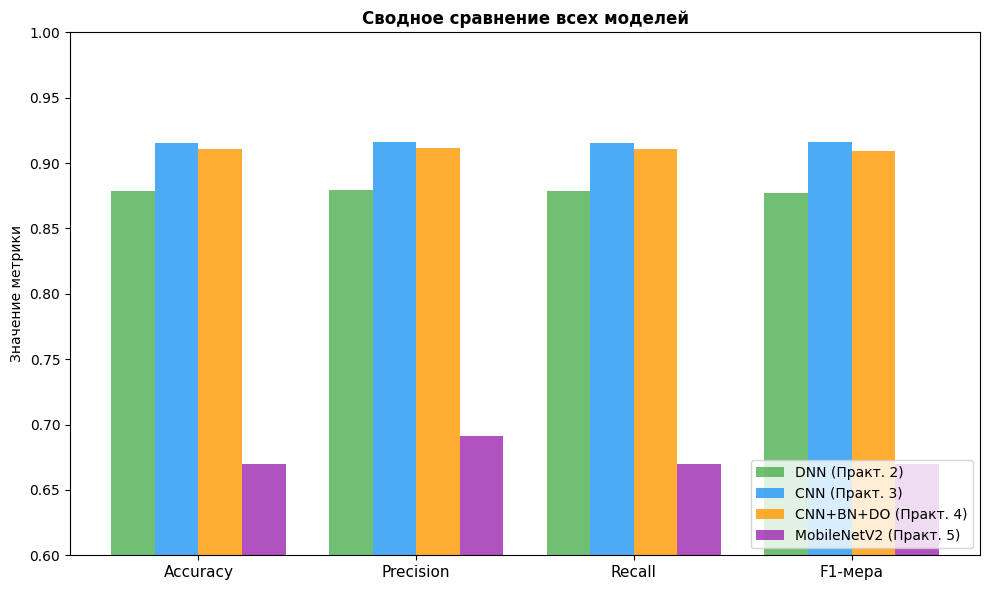

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(metrics))
width = 0.2
model_colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

for i, (_, row) in enumerate(df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x_pos + i * width, vals, width, label=row['Модель'],
           color=model_colors[i], alpha=0.8)

ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Значение метрики')
ax.set_title('Сводное сравнение всех моделей', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### 1.10. Выбор лучшей модели и сохранение

In [11]:
best_idx = df['F1-мера'].idxmax()
best_name = df.loc[best_idx, 'Модель']
best_f1 = df.loc[best_idx, 'F1-мера']

print(f'Лучшая модель по F1-мере: {best_name}')
print(f'F1-мера: {best_f1}')
print(f'Accuracy: {df.loc[best_idx, "Accuracy"]}')

best_model = trained_models[best_name]
best_model.save('best_classification_model.keras')
print('\nМодель сохранена: best_classification_model.keras')

Лучшая модель по F1-мере: CNN (Практ. 3)
F1-мера: 0.9159
Accuracy: 0.9157

Модель сохранена: best_classification_model.keras


---

### **Раздел 2. Развертывание API**

В этом разделе развёрнутый API должен принимать **любое** изображение, а не только одежду из Fashion MNIST. Поэтому в backend подгружается **CLIP-ViT-B/32** (OpenAI) в режиме *zero-shot classification* — модель сравнивает изображение с текстовыми эмбеддингами ~1400 меток из ImageNet-1k + Places365 + ручных категорий. Это позволяет распознавать **и объекты** (банан, собака, пицца), **и сцены** (лес, пляж, кухня, портрет).

На старте сервер один раз кодирует все текстовые подсказки `"a photo of {label}"` и кэширует эмбеддинги; при каждом запросе кодируется только изображение и считается косинусная похожесть — это быстро (≈0.3 с на CPU).

Что делает сервер `backend/main.py`:

1. Загружает модель `openai/clip-vit-base-patch32` и список меток из `backend/labels.txt`.
2. Один раз считает эмбеддинги всех меток (в формате `"a photo of {label}"`) и кэширует их.
3. Принимает POST с multipart-полем `file` на `/predict`, кодирует изображение через CLIP, считает softmax по косинусной похожести и возвращает топ-5 классов с уверенностью.
4. Дополнительно: `GET /` — описание API, `GET /health` — статус, CORS открыт для всех источников.

#### Код FastAPI приложения (main.py)

In [ ]:
%%writefile backend/main.py
"""FastAPI backend для универсального классификатора изображений.

Использует OpenAI CLIP-ViT-B/32 в режиме zero-shot classification.
В отличие от чистой ImageNet-модели, CLIP различает не только объекты
(собака, банан, пицца), но и сцены (лес, пляж, город, кухня и т.д.).
Словарь меток лежит в `labels.txt` — это объединение ImageNet-1k,
Places365 и нескольких ручных категорий (всего ~1400 классов).

При старте сервер один раз считает текстовые эмбеддинги всех меток
и затем при каждом запросе кодирует только изображение — это быстро.
"""

import io
import os
from typing import List

import torch
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

MODEL_NAME = os.environ.get('MODEL_NAME', 'openai/clip-vit-base-patch32')
LABELS_PATH = os.environ.get(
    'LABELS_PATH',
    os.path.join(os.path.dirname(__file__), 'labels.txt'),
)
TOP_K = int(os.environ.get('TOP_K', '5'))
PROMPT_TEMPLATE = os.environ.get('PROMPT_TEMPLATE', 'a photo of {label}')

app = FastAPI(
    title='Universal Image Classifier API',
    description=(
        'Универсальный zero-shot классификатор изображений на CLIP-ViT-B/32. '
        'Поддерживает и объекты (ImageNet), и сцены (Places365): '
        'лес/пляж/город/кухня/портрет и т.д. (~1400 классов).'
    ),
    version='4.0.0',
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=['*'],
    allow_credentials=True,
    allow_methods=['*'],
    allow_headers=['*'],
)


def _load_labels(path: str) -> List[str]:
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]


print(f'Loading CLIP model: {MODEL_NAME}')
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME).eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

LABELS: List[str] = _load_labels(LABELS_PATH)
print(f'Loaded {len(LABELS)} labels')

def _features(out):
    """Normalize the API: transformers 5.x returns a pooled output object."""
    return getattr(out, 'pooler_output', out)


print('Precomputing text features...')
_text_inputs = processor(
    text=[PROMPT_TEMPLATE.format(label=l) for l in LABELS],
    return_tensors='pt',
    padding=True,
    truncation=True,
).to(device)
with torch.no_grad():
    _text_features = _features(model.get_text_features(**_text_inputs))
_text_features = _text_features / _text_features.norm(dim=-1, keepdim=True)
print(f'Text features ready: {tuple(_text_features.shape)}')


def predict(image: Image.Image, k: int = TOP_K) -> List[dict]:
    """Возвращает топ-K (label, confidence) для одного изображения."""
    image = image.convert('RGB')
    inputs = processor(images=image, return_tensors='pt').to(device)
    with torch.no_grad():
        img_features = _features(model.get_image_features(**inputs))
    img_features = img_features / img_features.norm(dim=-1, keepdim=True)
    sims = (100.0 * img_features @ _text_features.T).softmax(dim=-1)[0]
    topk = torch.topk(sims, min(k, len(LABELS)))
    return [
        {
            'label': LABELS[i.item()],
            'confidence': round(float(v.item()), 6),
        }
        for v, i in zip(topk.values, topk.indices)
    ]


@app.get('/')
async def root():
    return {
        'message': 'Universal Image Classifier API',
        'model': f'CLIP-ViT-B/32 zero-shot ({MODEL_NAME})',
        'num_labels': len(LABELS),
        'top_k': TOP_K,
        'endpoints': {
            '/predict': 'POST image (multipart, поле file) — топ-K классов',
            '/health': 'GET healthcheck',
        },
    }


@app.get('/health')
async def health():
    return {
        'status': 'ok',
        'model_loaded': True,
        'num_labels': len(LABELS),
        'device': str(device),
    }


@app.post('/predict')
async def predict_endpoint(file: UploadFile = File(...)):
    contents = await file.read()
    image = Image.open(io.BytesIO(contents))
    top = predict(image, k=TOP_K)
    return {
        'predicted_class': top[0]['label'],
        'confidence': top[0]['confidence'],
        'top_k': top,
    }


#### Ответ:

**ССЫЛКА НА БЭКЕНД:** замени на свой URL после деплоя на Render.com (см. `HOW_TO_RUN.md`).

Эндпоинты:
- `GET /` — описание API + имя модели (CLIP-ViT-B/32, ~1400 классов).
- `GET /health` — `{"status":"ok","model_loaded":true,"num_labels":1397,"device":"cpu"}`.
- `POST /predict` — multipart-поле `file`, ответ:
  ```json
  {
    "predicted_class": "broadleaf forest",
    "confidence": 0.3992,
    "top_k": [
      {"label":"broadleaf forest","confidence":0.3992},
      {"label":"tree farm",       "confidence":0.2169},
      {"label":"forest path",     "confidence":0.1279},
      {"label":"forest road",     "confidence":0.0216},
      {"label":"wild field",      "confidence":0.0139}
    ]
  }
  ```

---

### **Раздел 3. Создание интерфейса на Streamlit**

1. Разработать Streamlit-приложение со следующими функциями:
   - Возможность загрузки изображения пользователем
   - Возможность рисования изображения на холсте
   - Предобработка изображения перед отправкой на API
   - Отображение результатов классификации
   - Визуализация распределения вероятностей по классам
2. Развернуть Streamlit-приложение на платформе Streamlit Cloud

#### Код Streamlit приложения (streamlit_app.py)

In [ ]:
%%writefile streamlit_app/streamlit_app.py
"""Streamlit интерфейс для универсального классификатора изображений."""

import io
import os

import matplotlib.pyplot as plt
import requests
import streamlit as st
from PIL import Image

DEFAULT_API_URL = os.environ.get('API_URL', 'http://localhost:8000/predict')

st.set_page_config(
    page_title='Universal Image Classifier', layout='centered'
)

st.title('Универсальный классификатор изображений')
st.caption('CLIP-ViT-B/32 · zero-shot · ~1400 классов (объекты + сцены)')
st.markdown(
    'Загрузите любое изображение — модель определит, что на нём, '
    'и покажет топ-5 наиболее вероятных классов.'
)


def _pretty(label: str) -> str:
    """`Egyptian_cat` → `Egyptian cat`, capitalize first letter."""
    s = label.replace('_', ' ').strip()
    if s and s[0].isalpha():
        s = s[0].upper() + s[1:]
    return s


api_url = st.sidebar.text_input('API URL', value=DEFAULT_API_URL)
st.sidebar.caption(
    'Эндпоинт FastAPI, который принимает изображение и возвращает классы.'
)

uploaded = st.file_uploader(
    'Выберите изображение', type=['png', 'jpg', 'jpeg', 'bmp', 'webp']
)

image_to_classify = None
if uploaded is not None:
    image_to_classify = Image.open(uploaded)
    st.image(image_to_classify, caption='Загруженное изображение', width=320)

if image_to_classify is not None and st.button('Классифицировать'):
    buf = io.BytesIO()
    image_to_classify.convert('RGB').save(buf, format='PNG')
    buf.seek(0)

    with st.spinner('Отправка на сервер...'):
        try:
            resp = requests.post(
                api_url,
                files={'file': ('image.png', buf, 'image/png')},
                timeout=60,
            )
            resp.raise_for_status()
            data = resp.json()

            st.success(
                f'**Предсказанный класс:** `{_pretty(data["predicted_class"])}`'
            )
            st.metric('Уверенность', f'{data["confidence"] * 100:.2f}%')

            top = data.get('top_k', [])
            if top:
                st.subheader('Топ-5 классов')
                labels = [_pretty(t['label']) for t in top][::-1]
                values = [t['confidence'] for t in top][::-1]
                fig, ax = plt.subplots(figsize=(10, 4))
                colors = ['#4CAF50' if i == len(values) - 1 else '#2196F3'
                          for i in range(len(values))]
                ax.barh(labels, values, color=colors)
                ax.set_xlabel('Уверенность')
                ax.set_xlim(0, 1)
                for i, v in enumerate(values):
                    ax.text(v + 0.01, i, f'{v*100:.1f}%', va='center', fontsize=9)
                plt.tight_layout()
                st.pyplot(fig)
        except requests.exceptions.ConnectionError:
            st.error(f'Не удалось подключиться к API: {api_url}')
        except Exception as e:
            st.error(f'Ошибка: {e}')


#### Ответ:

**ЗАПУСК ФРОНТЭНДА (локально):**

```bash
cd streamlit_app
pip install -r requirements.txt
streamlit run streamlit_app.py
```

В сайдбаре приложения укажите URL развернутого API (значение по умолчанию — `http://localhost:8000/predict`).

---

### **Раздел 4. Документация и публикация проекта**

#### Ответ:

**ПРОЕКТ:** все исходники собраны в zip-архив `practical10.zip` рядом с этим ноутбуком и могут быть запушены в любой публичный репозиторий (GitHub/GitLab) одной командой:

```bash
unzip practical10.zip && cd practical10
git init && git add . && git commit -m "Practical 10"
git remote add origin <URL_РЕПОЗИТОРИЯ>
git branch -M main && git push -u origin main
```